In [149]:
import pandas as pd
import numpy as np

In [150]:
df=pd.read_csv("Churn_Modelling.csv")

In [151]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [152]:
df.shape

(10000, 14)

In [153]:
df['Gender'].value_counts()
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [155]:
df.duplicated().sum()

np.int64(0)

In [156]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [157]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [158]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [159]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [160]:
df.shape

(10000, 11)

In [161]:
from sklearn.preprocessing import OneHotEncoder

In [162]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [163]:
geo_encoder=OneHotEncoder(sparse_output=False,drop='first')

In [164]:
encoded_data=geo_encoder.fit_transform(df[['Geography']])

In [165]:
encoded_data

array([[0., 0.],
       [0., 1.],
       [0., 0.],
       ...,
       [0., 0.],
       [1., 0.],
       [0., 0.]], shape=(10000, 2))

In [166]:
encoded_df = pd.DataFrame(
    encoded_data,
    columns=geo_encoder.get_feature_names_out(['Geography']),
    index=df.index
)

In [167]:
df=pd.concat([df,encoded_df],axis=1)

In [168]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.0,0.0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.0,0.0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0


In [169]:
df.drop(columns=['Geography'],inplace=True)

In [170]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,Female,42,2,0.00,1,1,1,101348.88,1,0.0,0.0
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0
3,699,Female,39,1,0.00,2,0,0,93826.63,0,0.0,0.0
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0


In [171]:
df=pd.get_dummies(df,columns=['Gender'],drop_first=True)



In [172]:

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.0,0.0,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0,False
2,502,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.0,0.0,False
4,850,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0,False


In [173]:
from sklearn.model_selection import train_test_split


In [174]:
X=df.drop(columns=['Exited'])


In [175]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0.0,0.0,False
1,608,41,1,83807.86,1,0,1,112542.58,0.0,1.0,False
2,502,42,8,159660.80,3,1,0,113931.57,0.0,0.0,False
3,699,39,1,0.00,2,0,0,93826.63,0.0,0.0,False
4,850,43,2,125510.82,1,1,1,79084.10,0.0,1.0,False


In [176]:
y=df['Exited']

In [177]:
X_train,X_test,y_trian,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [178]:
X_train.shape

(8000, 11)

In [179]:
from sklearn.preprocesing import  Stand

ModuleNotFoundError: No module named 'sklearn.preprocesing'

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)


array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model=Sequential()

In [ ]:
model.add(Dense(3,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

C:\Users\Waqas Raza\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │            44 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220 (884.00 B)

 Trainable params: 114 (456.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 106 (428.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='Adam')


In [185]:
history=model.fit(X_train_scaled,y_trian,epochs=20,validation_split=0.2)


Epoch 1/20


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3984 - val_loss: 0.6903
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3983 - val_loss: 0.6904
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3982 - val_loss: 0.6904
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3983 - val_loss: 0.6904
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3982 - val_loss: 0.6904
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3982 - val_loss: 0.6904
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3981 - val_loss: 0.6904
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3980 - val_loss: 0.6904
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3979 - val_loss: 0.6904
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3979 - val_loss: 0.6904
Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3979 - val_loss: 0.6904
Epoch 12/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.

{'loss': [0.39840057492256165,
  0.39829960465431213,
  0.39823126792907715,
  0.3982701599597931,
  0.39822280406951904,
  0.39815789461135864,
  0.39809685945510864,
  0.39803504943847656,
  0.39789485931396484,
  0.3978625535964966,
  0.3978837728500366,
  0.39786145091056824,
  0.397769957780838,
  0.3977168798446655,
  0.397684782743454,
  0.3976156711578369,
  0.39756888151168823,
  0.39754748344421387,
  0.3975449800491333,
  0.39750897884368896],
 'val_loss': [0.6903407573699951,
  0.6903691291809082,
  0.6903681755065918,
  0.6904250383377075,
  0.6904419660568237,
  0.6903685927391052,
  0.6903733611106873,
  0.6903675198554993,
  0.6904130578041077,
  0.6903882622718811,
  0.6904059052467346,
  0.6903880834579468,
  0.6904115080833435,
  0.6904135346412659,
  0.690415620803833,
  0.6904515027999878,
  0.6904705762863159,
  0.6904780864715576,
  0.6903563141822815,
  0.6903329491615295]}

In [ ]:
model.layers[0].get_weights()

[array([[ 0.08809341,  0.05649858,  0.06924841],
        [ 0.20043002, -2.3850164 , -3.728123  ],
        [ 0.16491395,  0.04512166, -0.13809884],
        [-0.42804515, -0.62965655,  0.24970195],
        [ 0.15326963,  0.12325969, -0.06750769],
        [ 0.03263501,  0.16257007, -0.2070926 ],
        [ 2.26644   ,  0.19400185, -0.71355   ],
        [ 0.12123518, -0.15597574, -0.06459112],
        [-0.7620209 , -0.90838695, -0.0737504 ],
        [-0.02802836, -0.02360989, -0.05217238],
        [ 0.7649399 ,  0.7645972 , -0.2217223 ]], dtype=float32),
 array([-0.23260622, -0.45117605,  0.51944906], dtype=float32)]

In [ ]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
y_pred=np.where(y_log>0.5,1,0)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)


0.835

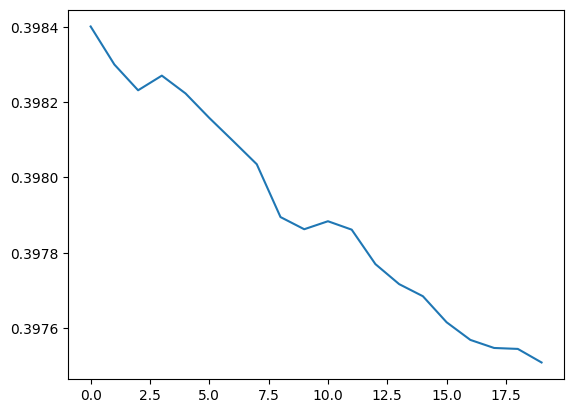

In [195]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])



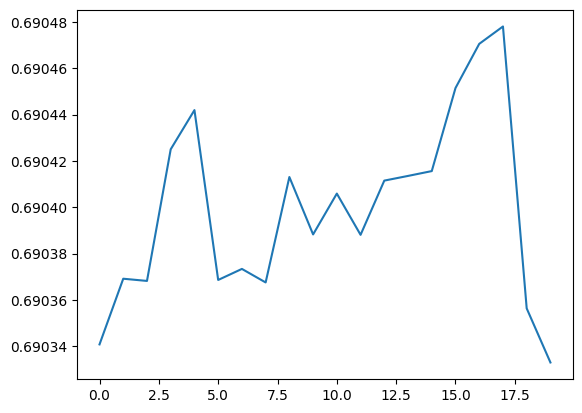

In [196]:
plt.plot(history.history['val_loss'])